In [7]:
import numpy as np
import pandas as pd
from utils import plot_economic_metrics, plot
from environment import agentDLVEnvV1
import os
import shutil
import random
import torch
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.callbacks import CallbackList
from ReLuExtractor import ReLUFeatureExtractor

In [8]:
df = pd.read_csv('weth_island_data.csv')
nav = df['nav'].values
nect_price = pd.read_csv('nect_honey_price.csv')['price'].values
vol_token_price = pd.read_csv('weth_honey_price.csv')['price'].values
volatile_part = df['wbtc_frac'].values
timestamp = df['timestamp'].values

In [9]:
TARGET_LEVERAGE = 2

In [10]:
def naiveAgent(obs, target_leverage = 2, max_step = 0.15, deviation = 0.01):

    nect = obs[0]
    leverage = obs[3] + target_leverage
    colateral_value = obs[1]
    volatile_part_value = obs[2]

    if abs(leverage - target_leverage)/target_leverage<=deviation:
        return 0
    else: 
        return 1

In [11]:
def make_calm(i):
    def _init():
        env = agentDLVEnvV1(
            nect_honey_price = nect_price,
            LP_nav_honey = nav,
            volatile_part = volatile_part,
            vol_token_price = vol_token_price,
            is_training = True,
            target_leverage = TARGET_LEVERAGE
        )
        return Monitor(env)
    return _init

def make_vol(i):
    def _init():
        env = agentDLVEnvV1(
            nect_honey_price = nect_price,
            LP_nav_honey = nav,
            volatile_part = volatile_part,
            vol_token_price = vol_token_price,
            is_training = True,
            target_leverage = TARGET_LEVERAGE
        )
        return Monitor(env)
    return _init

vec_env = DummyVecEnv([make_calm(0), make_vol(0)])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True)

policy_kwargs = dict(
    features_extractor_class=ReLUFeatureExtractor,
    features_extractor_kwargs=dict(features_dim=64)
)


model_1 = PPO(
    "MlpPolicy",
    vec_env,
    learning_rate=1e-5,  
    ent_coef=1e-4,       
    verbose=1,
    policy_kwargs=policy_kwargs,
    n_steps=1024,
    vf_coef = 1,
    device="cpu" 
)

model_1.set_parameters("loop_model_weth/ppo_model_final.zip")


Using cpu device


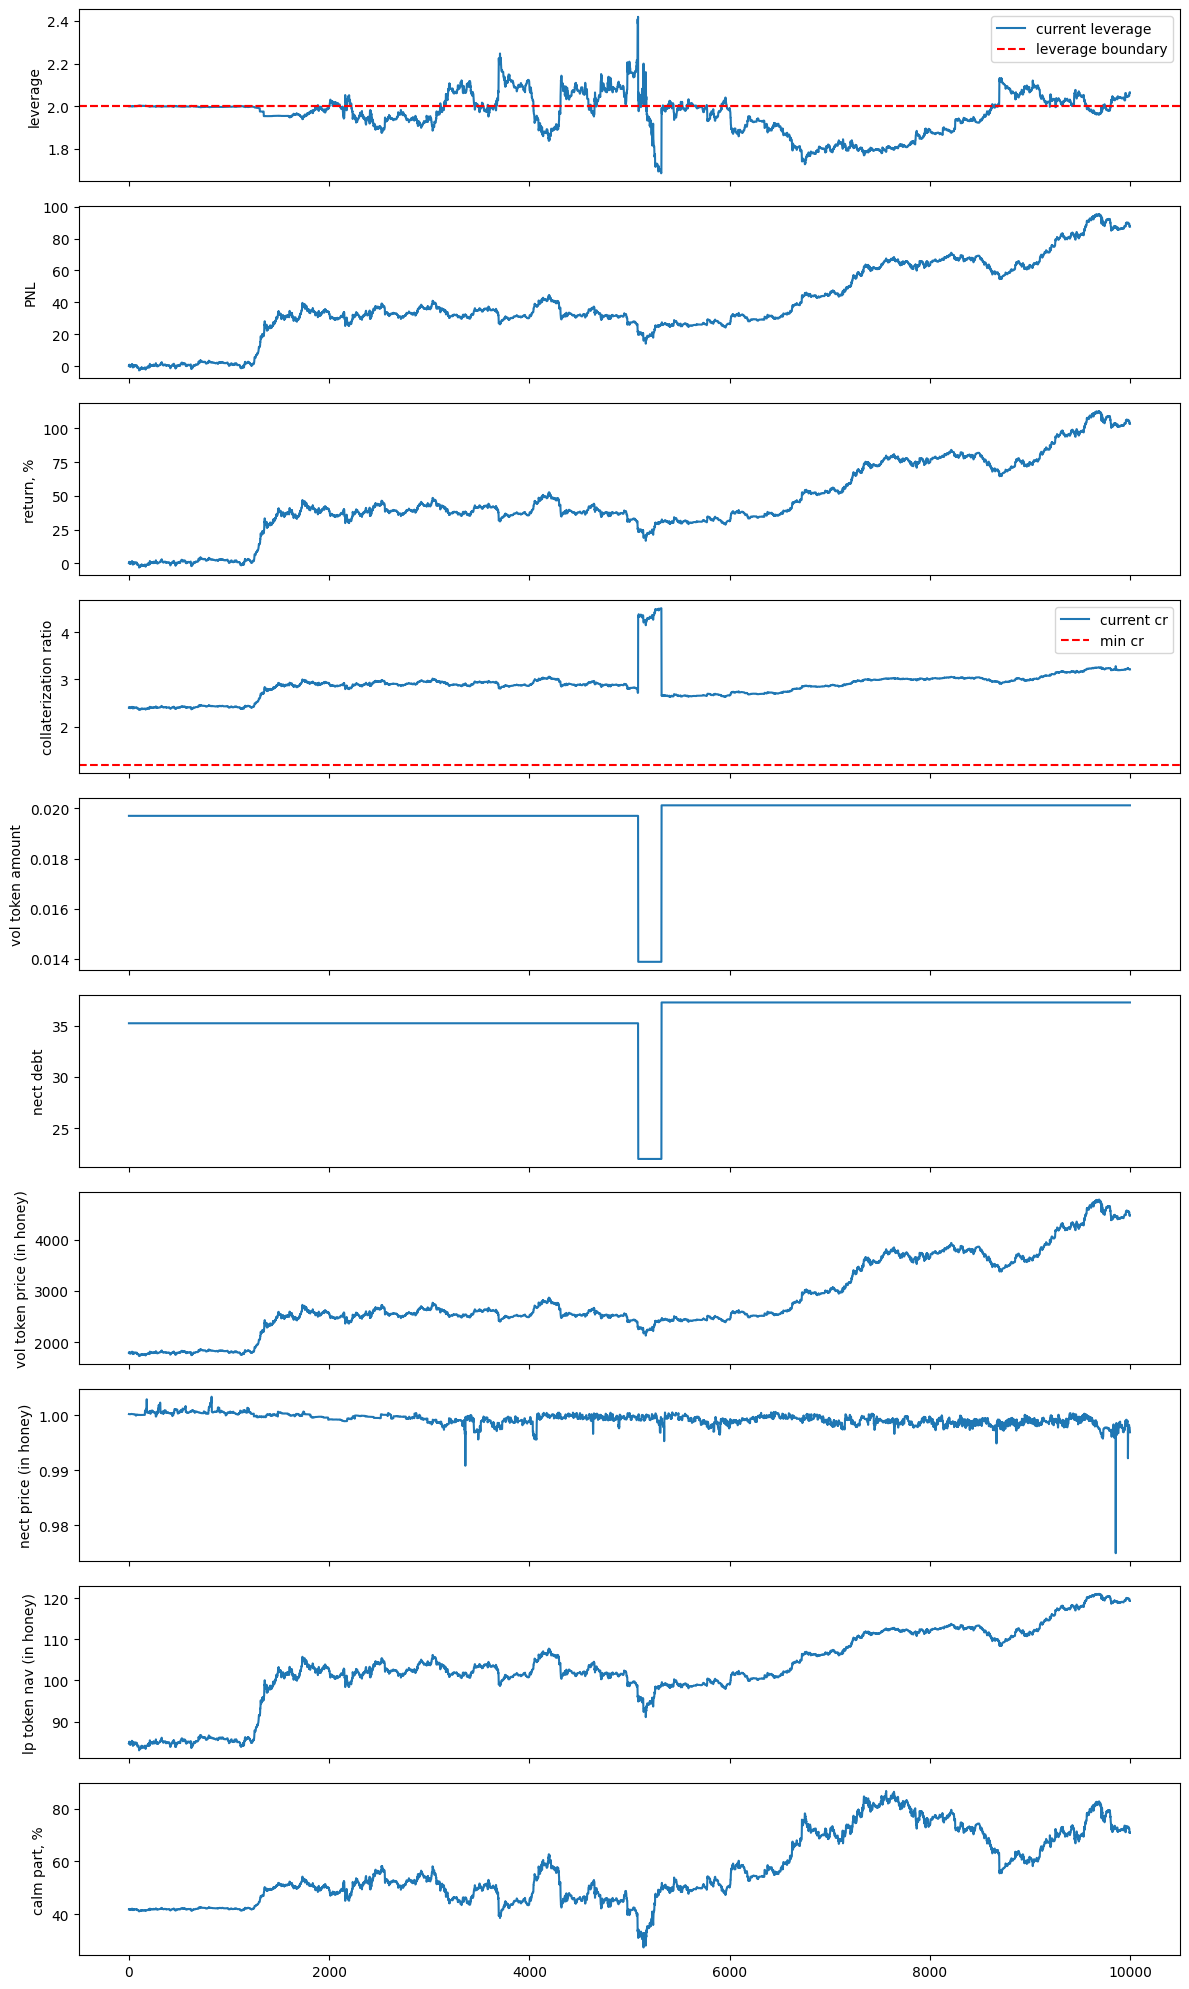

In [12]:
eval_env_vol = DummyVecEnv([lambda: agentDLVEnvV1(
    nect_honey_price = nect_price,
    LP_nav_honey = nav,
    volatile_part = volatile_part,
    vol_token_price = vol_token_price,
    is_training=False,
    target_leverage=TARGET_LEVERAGE
)])
eval_env_vol = VecNormalize.load("loop_model_weth/vecnormalize_stats.pkl", eval_env_vol)
eval_env_vol.training = False
eval_env_vol.norm_reward = False

obs = eval_env_vol.reset()   
done = False
while not done:
    action, _ = model_1.predict(obs, deterministic=True)  
    obs, rewards, dones, infos = eval_env_vol.step(action)
    done = dones[0]
    if dones[0]:
        economic_metrics = infos[0].get('episode_economics')   
        break


plot_economic_metrics(economic_metrics, TARGET_LEVERAGE, TARGET_LEVERAGE)

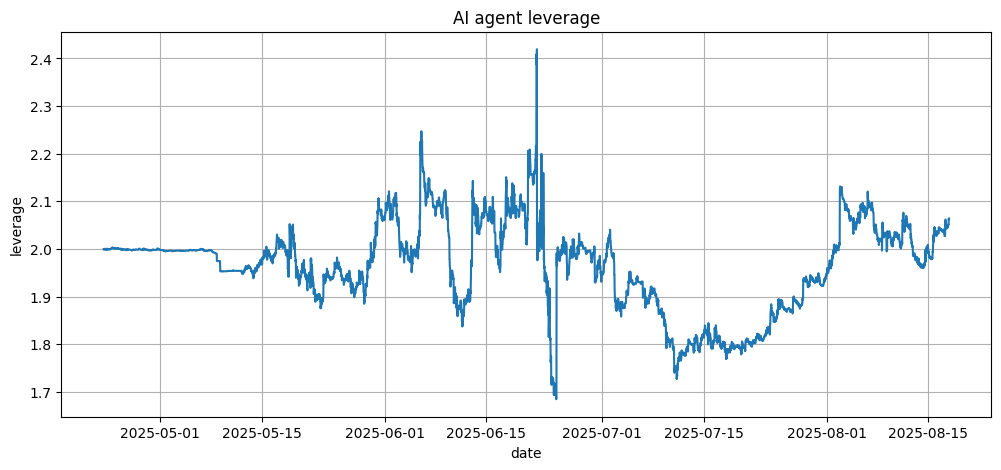

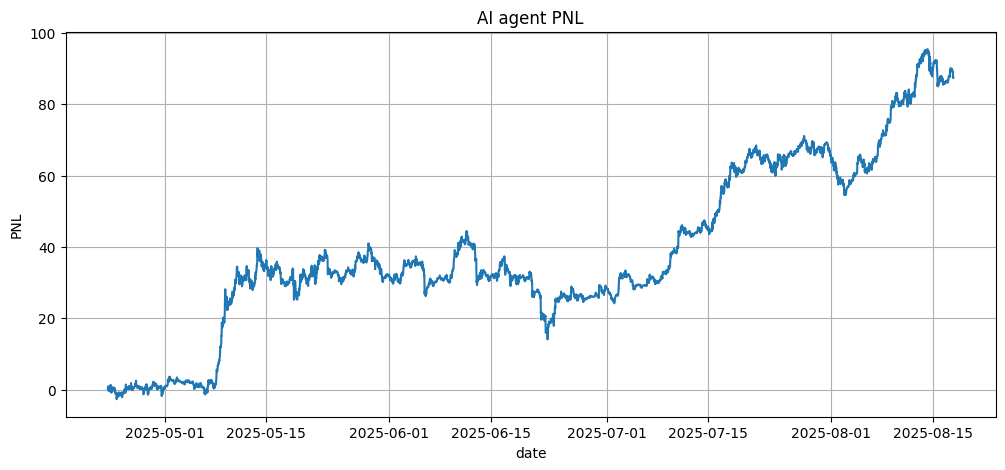

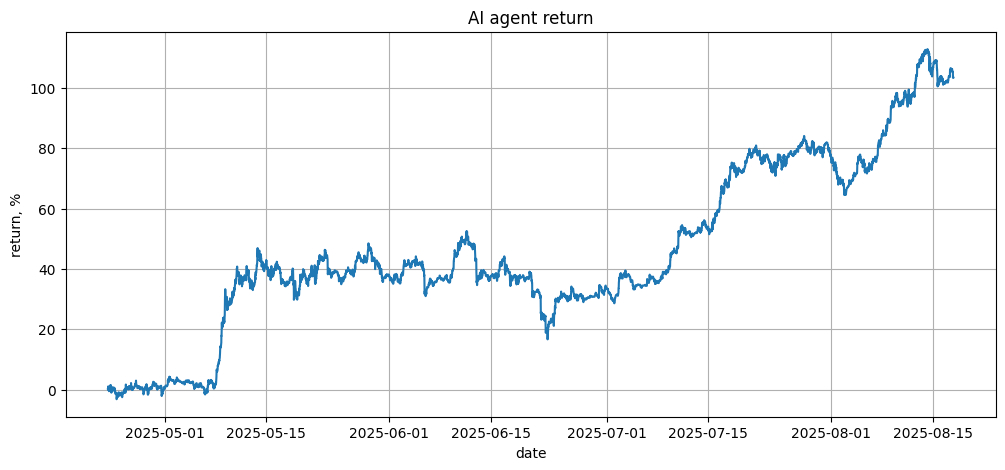

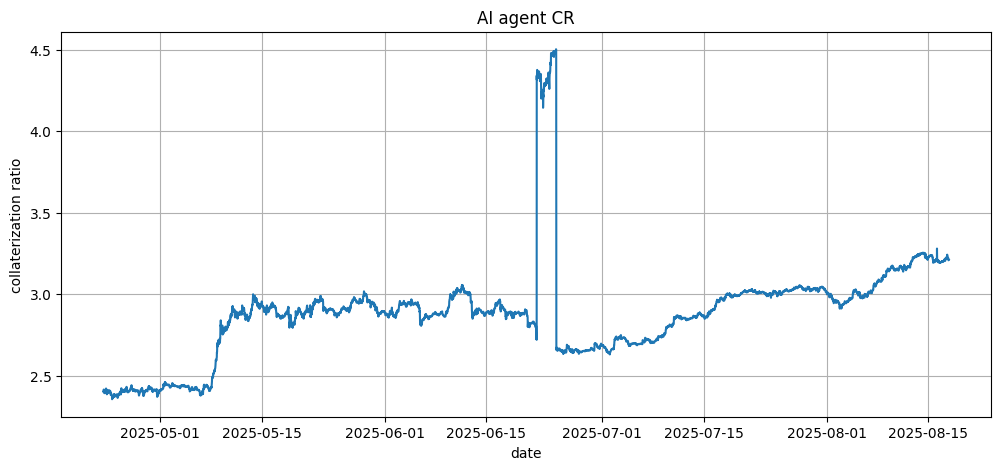

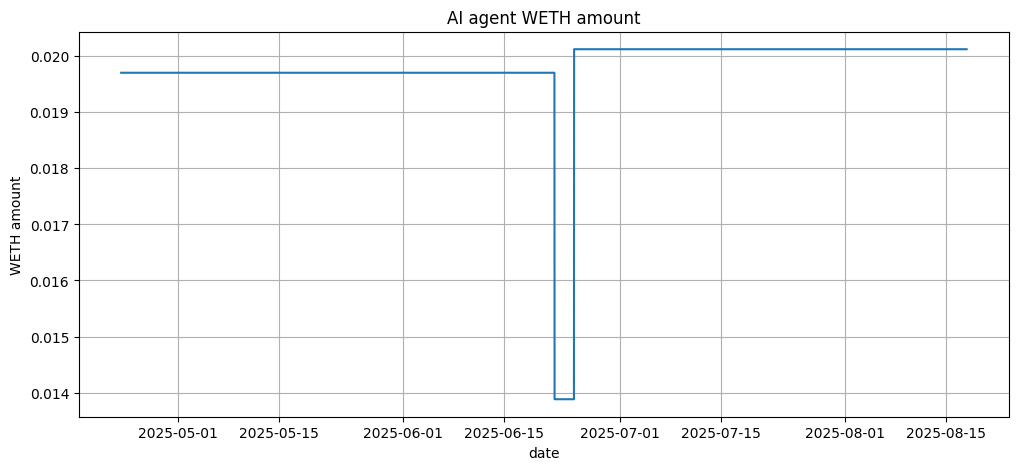

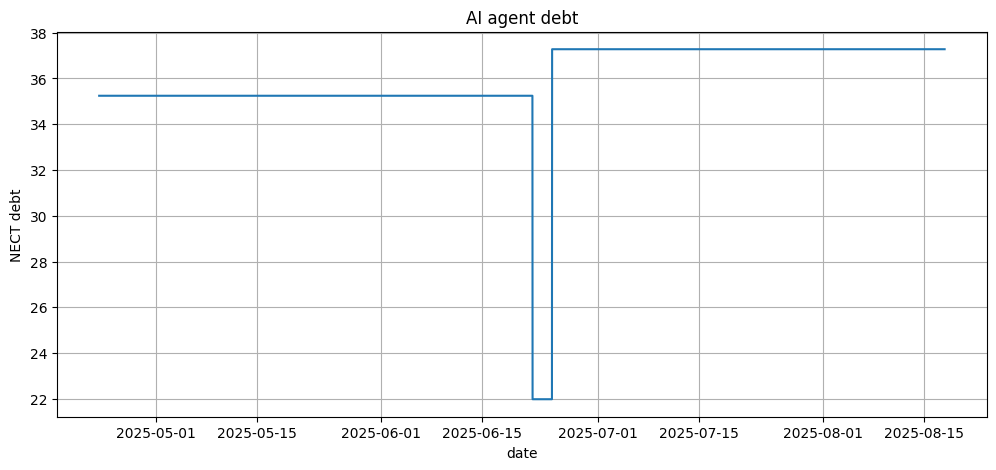

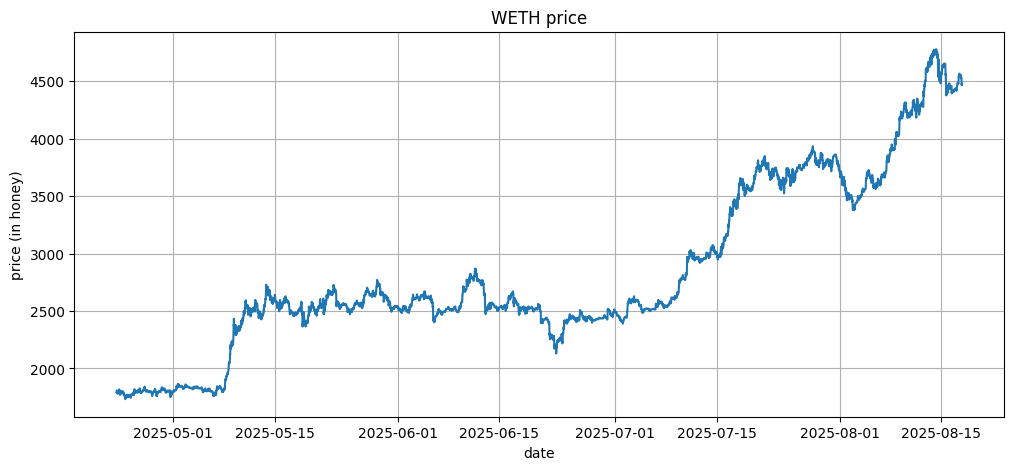

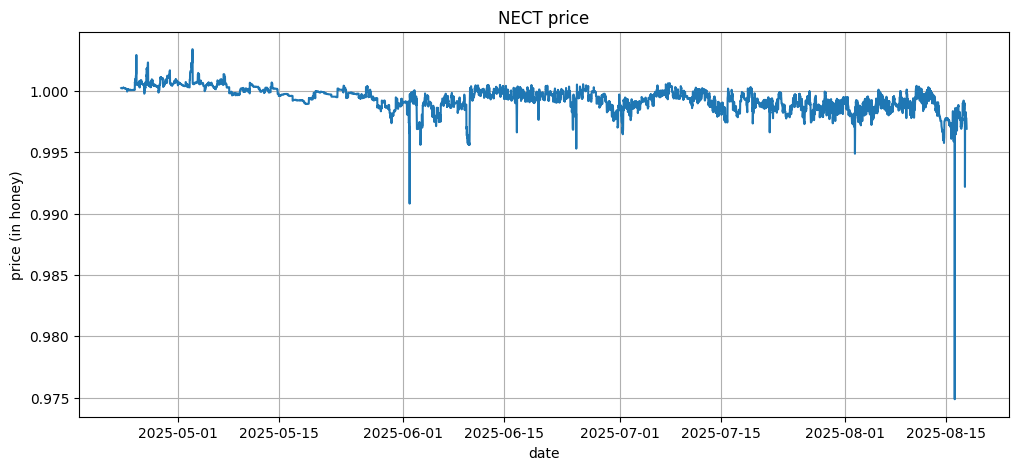

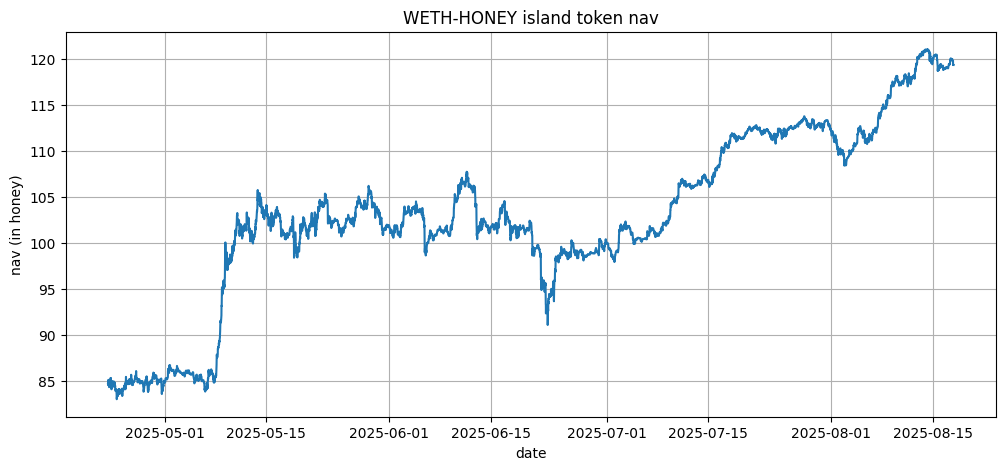

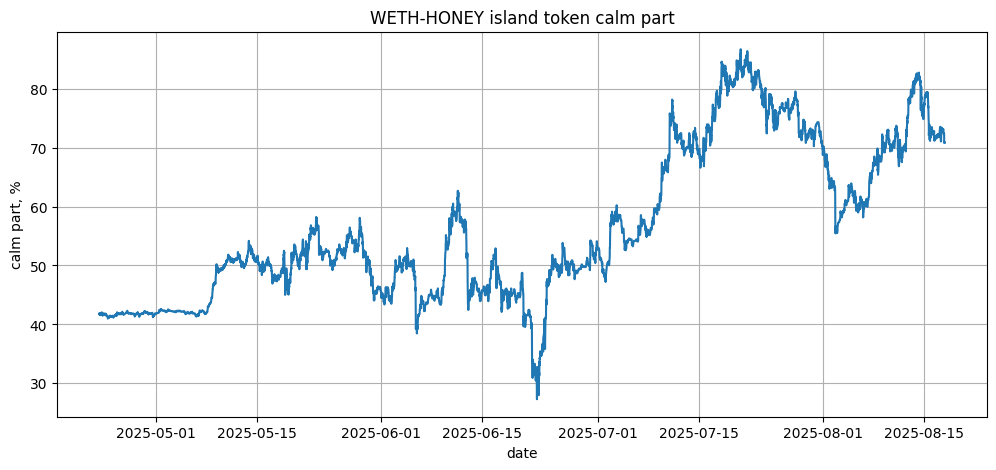

In [16]:
date = timestamp.astype("datetime64[s]")[1:]

plot(
    date,
    economic_metrics['leverage'],
    'date',
    'leverage',
    'AI agent leverage'
)

plot(
    date,
    economic_metrics['PNL'],
    'date',
    'PNL',
    'AI agent PNL'
)

plot(
    date,
    np.array(economic_metrics['return'])*100,
    'date',
    'return, %',
    'AI agent return'
)

plot(
    date,
    economic_metrics['collaterization ratio'],
    'date',
    'collaterization ratio',
    'AI agent CR'
)

plot(
    date,
    economic_metrics['vol token amount'],
    'date',
    'WETH amount',
    'AI agent WETH amount'
)

plot(
    date,
    economic_metrics['nect debt'],
    'date',
    'NECT debt',
    'AI agent debt'
)

plot(
    date,
    economic_metrics['vol token price'],
    'date',
    'price (in honey)',
    'WETH price'
)

plot(
    date,
    economic_metrics['nect price'],
    'date',
    'price (in honey)',
    'NECT price'
)

plot(
    date,
    economic_metrics['nav'],
    'date',
    'nav (in honey)',
    'WETH-HONEY island token nav'
)

plot(
    date,
    np.array(economic_metrics['calm part'])*100,
    'date',
    'calm part, %',
    'WETH-HONEY island token calm part'
)